## You only have to edit cell 3 with the correct path to your data file.

In [1]:
import time
import gc

import numpy as np
import jax
import jax.numpy as jnp
from jax import lax, vmap, jit
import matplotlib.pyplot as plt
import pymaster as nmt
import healpy as hp
from scipy.integrate import simpson
from tqdm import tqdm
from astropy.coordinates import SkyCoord
from astropy.io import fits
from astropy import units as u
from pathlib import Path

from brute_cov import build_binning_matrix, pad_binning_matrix, cos_theta_pair, cos_theta_row, cos_theta_matrix, compute_cos_theta, mcm_binning, batch_covariace, batch_matrix_partitions, load_pcl_dataset, compute_legendre
from utils2 import *

In [2]:
compute_legendre_jitted = jax.jit(compute_legendre, static_argnames='lmax')
full_covariace_jitted = jax.jit(batch_covariace, static_argnames=('lmax'))
full_covariance = jax.vmap(full_covariace_jitted, in_axes=(0, 0, 0, 0, 0, 0, 0, 0, None, None, None, None, None))
@jax.jit
def corr(s, P):
    return jnp.einsum('l, lij->ij', s, P)


In [3]:
input_path = Path('/home/s59efara_hpc/covariance/data_sets/mock_catalogues_catalog.fits')

data = load_pcl_dataset(input_path)

In [4]:
theory_binned = data["theory_binned"]

In [5]:
RA = data['RA']
DEC = data['DEC']
DM = data['series']['DM']
# DM_gaussian = data['series']['DM_gaussian']
# DM_lognormal = data['series']['DM_lognormal']

transformation = SkyCoord(ra=RA*u.degree, dec=DEC*u.degree, frame='icrs').galactic
gl, gb = np.array(transformation.l), np.array(transformation.b)
pos = np.array([gl, gb])

In [6]:
edges = data['pcl_edges']
lmin = np.min(edges)
lmax_nside = np.max(edges)
lmax = lmax_nside
b = nmt.NmtBin.from_edges(edges[:-1], edges[1:])
w = np.ones(gl.size)

In [7]:
posi_list, posj_list, posa_list, posb_list, wi_list, wj_list, wa_list, wb_list = batch_matrix_partitions(pos, w, partition = 1500)

In [8]:
f_mask = nmt.NmtFieldCatalog(positions = [gl, gb], weights = w, field= None,
                         lmax = b.lmax, spin = 0, lonlat=True )    


wasp = nmt.NmtWorkspace.from_fields(f_mask, f_mask, b)
mcm = jnp.asarray(wasp.get_coupling_matrix())
mcm_inv = np.linalg.inv(mcm)


In [9]:
Binning, ell_eff = build_binning_matrix(edges)
Binning_matrix_padded = pad_binning_matrix(Binning, lmin, lmax)
Binning_matrix_padded = jnp.array(Binning_matrix_padded)
TB = Binning_matrix_padded @ mcm_inv

In [10]:
with fits.open(input_path) as hdul:
    DM = hdul['REAL_00001'].data['DM']

f = nmt.NmtFieldCatalog(positions = [gl, gb], weights=w, field = DM, lmax=b.lmax, lonlat=True, spin = 0)

Sl_coupled = nmt.compute_coupled_cell(f, f) # the coupled, noise subtracted power spectrum  
Nf = f.Nf
Sl = wasp.decouple_cell(Sl_coupled)
Sl_unbinned = b.unbin_cell(Sl)[0]
# Sl_unbinned[0] = Sl_unbinned[int(edges[0])]
# Sl_unbinned[1] = Sl_unbinned[int(edges[0])]
ells = b.get_effective_ells()



full_ells = jnp.arange(0, edges[-1])
field_variance = jnp.sum((2*full_ells + 1)*Sl_unbinned)/4./np.pi
var_f = np.var(DM) + np.mean(DM)**2

noise_variance = var_f - field_variance

In [11]:
def sum_matrices(pos, w, TB, lmax, full_ells, Sl_unbinned, noise_variance, chunk_size):
    
    # Pad pos and w so that N is a multiple of chunk_size
    N = pos.shape[1]
    remainder = N % chunk_size
    if remainder != 0:
        pad_size = chunk_size - remainder
        pos = jnp.concatenate([pos, jnp.zeros((pos.shape[0], pad_size))], axis=1)
        w   = jnp.concatenate([w,   jnp.zeros(pad_size)])

    n_chunks = pos.shape[1] // chunk_size
    dim_cov = TB.shape[0]
    carry_init = jnp.zeros((dim_cov, dim_cov))
    
    def sum_over_i(i, carr_i):
        posi = lax.dynamic_slice(pos, (0, i*chunk_size), (2, chunk_size))
        wi = lax.dynamic_slice(w, (i*chunk_size,), (chunk_size, ))
                
        def sum_over_j(j, carr_j):
            posj = lax.dynamic_slice(pos, (0, j*chunk_size), (2, chunk_size))
            wj = lax.dynamic_slice(w, (j*chunk_size,), (chunk_size, ))
            
            w_ij = wi[:, None] * wj[None, :]
            w_ij = lax.cond(jnp.all(posi == posj), lambda x: x - jnp.diag(jnp.diag(x)), lambda x: x, w_ij)
            
            cos_theta_ij = compute_cos_theta(posi[0], posi[1], posj[0], posj[1])
            P_ij = compute_legendre_jitted(cos_theta_ij, lmax)
            TBP_ij = mcm_binning(TB, P_ij)
            
            del P_ij, cos_theta_ij
            
            def sum_over_a(a, carr_a):
                posa = lax.dynamic_slice(pos, (0, a*chunk_size), (2, chunk_size))
                wa = lax.dynamic_slice(w, (a*chunk_size,), (chunk_size, ))
                
                def sum_over_b(b, carr_b):
                    posb = lax.dynamic_slice(pos, (0, b*chunk_size), (2, chunk_size))
                    wb = lax.dynamic_slice(w, (b*chunk_size,), (chunk_size, ))
                    
                    w_ab = wa[:, None] * wb[None, :]
                    w_ab = lax.cond(jnp.all(posa == posb), lambda x: x - jnp.diag(jnp.diag(x)), lambda x: x, w_ab)
                    
                    cos_theta_ab = compute_cos_theta(posa[0], posa[1], posb[0], posb[1])
                    P_ab = compute_legendre_jitted(cos_theta_ab, lmax)    
                    TBP_ab = mcm_binning(TB, P_ab)
                    del P_ab, cos_theta_ab
                    
                    cos_theta_ia = compute_cos_theta(posi[0], posi[1], posa[0], posa[1])
                    P_ia = compute_legendre_jitted(cos_theta_ia, lmax)    
                    signal_corr_ia = corr((2*full_ells + 1) *Sl_unbinned, P_ia)/4./np.pi
                    del P_ia, cos_theta_ia
                    
                    cos_theta_jb = compute_cos_theta(posj[0], posj[1], posb[0], posb[1])
                    P_jb = compute_legendre_jitted(cos_theta_jb, lmax)
                    signal_corr_jb = corr((2*full_ells + 1) *Sl_unbinned, P_jb)/4./np.pi
                    del cos_theta_jb, P_jb
                    
                    noise_variance_matrix = noise_variance*jnp.eye(wi.size)
    
                    full_field_corr_ia = lax.cond(jnp.all(posi == posa), lambda s, n: s + n, lambda s, n: s, signal_corr_ia, noise_variance_matrix)
                    full_field_corr_jb = lax.cond(jnp.all(posj == posb), lambda s, n: s + n, lambda s, n: s, signal_corr_jb, noise_variance_matrix)
                    del signal_corr_ia, signal_corr_jb, noise_variance_matrix
                    
                    Cov_binned = 2*jnp.einsum('ij, aij, km, bkm, ik, jm->ab', w_ij, TBP_ij, w_ab, TBP_ab, full_field_corr_ia, full_field_corr_jb)/(4*np.pi)**2 + carr_b
                    jax.debug.print('The value of the indices is {} {} {} {}', i, j, a, b)
                    
                    return Cov_binned
                return lax.fori_loop(0, n_chunks, sum_over_b, carr_a)
            return lax.fori_loop(0, n_chunks, sum_over_a, carr_j)
        return lax.fori_loop(0, n_chunks, sum_over_j, carr_i)
    outer_sum = jax.lax.fori_loop(0, n_chunks, sum_over_i, carry_init)
    return outer_sum

In [12]:
sum_matrices_jitted = jit(sum_matrices, static_argnames=('lmax', 'chunk_size'))
cov_gpu = sum_matrices_jitted(pos, w, TB, int(edges[-1]), full_ells, Sl_unbinned, noise_variance, 2000)

The value of the indices is 0 0 0 0
The value of the indices is 0 0 0 1
The value of the indices is 0 0 1 0
The value of the indices is 0 0 1 1
The value of the indices is 0 1 0 0
The value of the indices is 0 1 0 1
The value of the indices is 0 1 1 0
The value of the indices is 0 1 1 1
The value of the indices is 1 0 0 0
The value of the indices is 1 0 0 1
The value of the indices is 1 0 1 0
The value of the indices is 1 0 1 1
The value of the indices is 1 1 0 0
The value of the indices is 1 1 0 1
The value of the indices is 1 1 1 0
The value of the indices is 1 1 1 1


In [14]:
np.save(f'/home/s59efara_hpc/covariance/GPU_data/cov_chime.npy', cov_gpu)

In [15]:
cl_th = data['theory_cl']
cl_th = np.concatenate([np.array([0, 0]), cl_th])

cl_th_coupled = wasp.couple_cell(cl_th[None, :])
cl_th_decoupled = wasp.decouple_cell(cl_th_coupled)
cl_th_decoupled_unbinned = b.unbin_cell(cl_th_decoupled)[0]



print(cl_th_decoupled.shape, full_ells.shape)
field_variance = jnp.sum((2*full_ells + 1)*cl_th_decoupled_unbinned)/4./np.pi
var_f = np.var(DM) + np.mean(DM)**2
noise_variance = var_f - field_variance

(1, 12) (171,)


In [16]:
cov_gpu_th = sum_matrices_jitted(pos, w, TB, int(edges[-1]), full_ells, cl_th_decoupled_unbinned, noise_variance, 2000)

The value of the indices is 0 0 0 0
The value of the indices is 0 0 0 1
The value of the indices is 0 0 1 0
The value of the indices is 0 0 1 1
The value of the indices is 0 1 0 0
The value of the indices is 0 1 0 1
The value of the indices is 0 1 1 0
The value of the indices is 0 1 1 1
The value of the indices is 1 0 0 0
The value of the indices is 1 0 0 1
The value of the indices is 1 0 1 0
The value of the indices is 1 0 1 1
The value of the indices is 1 1 0 0
The value of the indices is 1 1 0 1
The value of the indices is 1 1 1 0
The value of the indices is 1 1 1 1


In [18]:
print('covariance calculated, saving to disk...')
np.save(f'/home/s59efara_hpc/covariance/GPU_data/cov_chime_theory.npy', cov_gpu_th)

covariance calculated, saving to disk...


In [19]:
# Covariance and correlation-coefficient matrices for every pseudo-C_ell case and input file.

# Requires Cell 1 to have defined: datasets
datasets = [data]




covariance_mats = {}

correlation_mats = {}



for dataset in datasets:

    dataset_label = dataset["label"]

    covariance_mats[dataset_label] = {}

    correlation_mats[dataset_label] = {}



    for label, values in dataset["series"].items():

        arr = np.asarray(values, dtype=float)

        cov = np.cov(arr, rowvar=False, ddof=1)

        sigma = np.sqrt(np.diag(cov))

        denom = np.outer(sigma, sigma)

        corr = np.divide(cov, denom, out=np.zeros_like(cov), where=denom > 0)

        covariance_mats[dataset_label][label] = cov

        correlation_mats[dataset_label][label] = corr



print("Computed covariance and correlation matrices:")

for dataset in datasets:

    dataset_label = dataset["label"]

    for label in dataset["series"]:

        shape = covariance_mats[dataset_label][label].shape

        print(f"  {dataset_label} | {label}: shape = {shape}")



series_labels = list(datasets[0]["series"].keys())

Computed covariance and correlation matrices:
  mock_catalogues_catalog | DM: shape = (12, 12)
  mock_catalogues_catalog | DM + Gaussian noise: shape = (12, 12)
  mock_catalogues_catalog | DM + lognormal noise: shape = (12, 12)


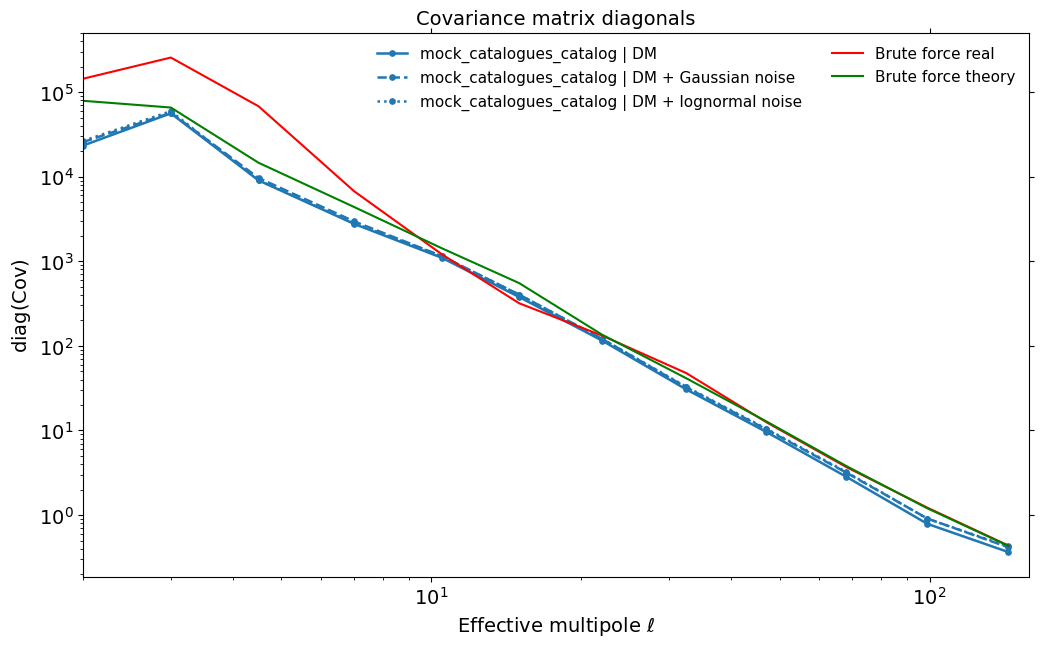

In [23]:

series_labels = list(datasets[0]["series"].keys())

colors = plt.cm.tab10(np.linspace(0, 1, len(datasets)))

line_styles = ["-", "--", ":", "-."]



fig, ax = plt.subplots(figsize=(11.0, 6.8))

y_chunks = []



for color, dataset in zip(colors, datasets):

    dataset_label = dataset["label"]

    ell_eff = dataset["ell_eff"]



    for index, label in enumerate(series_labels):

        cov_diag = np.diag(covariance_mats[dataset_label][label])

        ax.plot(

            ell_eff,

            cov_diag,

            marker="o",

            ms=3.8,

            lw=1.8,

            color=color,

            ls=line_styles[index % len(line_styles)],

            label=f"{dataset_label} | {label}",

        )
        # print(np.diagonal(cov_gpu_th)/cov_diag, label)

        finite = cov_diag[np.isfinite(cov_diag)]

        if finite.size:

            y_chunks.append(finite)



y_stack = np.concatenate(y_chunks) if y_chunks else np.array([1.0])

y_min = np.nanmin(y_stack)

y_max = np.nanmax(y_stack)

if y_min > 0:

    ax.set_yscale("log")

    #ax.set_ylim(0.1 * y_min, 1.25 * y_max)

else:

    y_abs_max = np.nanmax(np.abs(y_stack)) if y_stack.size else 1.0

    linthresh = max(1e-12, 1e-4 * y_abs_max)

    ax.set_yscale("symlog", linthresh=linthresh)

ax.plot(ell_eff, np.diagonal(cov_gpu), color = 'red', label = 'Brute force real')
ax.plot(ell_eff, np.diagonal(cov_gpu_th), color = 'green', label = 'Brute force theory')

xmin = min(dataset["ell_eff"].min() for dataset in datasets)

xmax = max(dataset["ell_eff"].max() for dataset in datasets)

ax.set_xscale("log")

ax.set_xlim(max(2.0, 0.9 * xmin), 1.1 * xmax)
fontsi2 = 14
ax.set_xlabel(r"Effective multipole $\ell$", fontsize=fontsi2)

ax.set_ylabel(r"diag$\left(\mathrm{Cov}\right)$", fontsize=fontsi2)

ax.set_title("Covariance matrix diagonals", fontsize=fontsi2)
fontsi = 14
ax.tick_params(labelsize=fontsi, top=True, right=True)


ax.legend(fontsize=fontsi - 3, frameon=False, loc="best", ncol=2)

fig.subplots_adjust(left=0.12, right=0.98, bottom=0.12, top=0.92)
fig.savefig("/home/s59efara_hpc/covariance/figs/cov_chime.png")
plt.show()


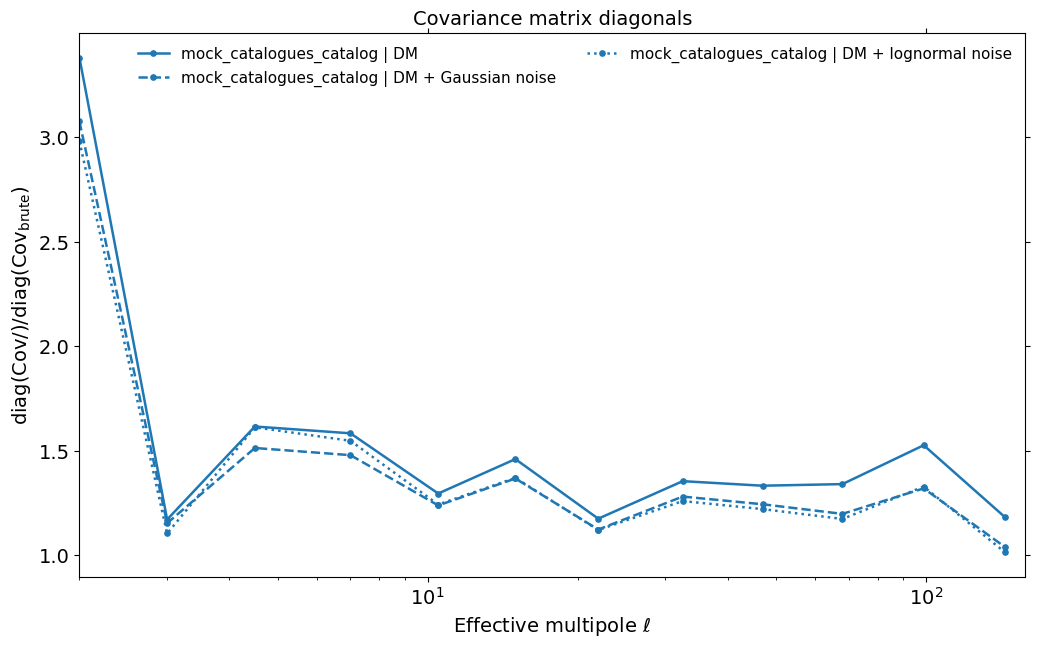

In [25]:
# Diagonals of the covariance matrices on a single plot.

# Requires Cell 2 to have defined: covariance_mats and datasets

if "covariance_mats" not in globals() or "datasets" not in globals() or not datasets:

    raise ValueError("Run Cells 1 and 2 first so 'covariance_mats' and 'datasets' are defined.")



series_labels = list(datasets[0]["series"].keys())

colors = plt.cm.tab10(np.linspace(0, 1, len(datasets)))

line_styles = ["-", "--", ":", "-."]



fig, ax = plt.subplots(figsize=(11.0, 6.8))

y_chunks = []



for color, dataset in zip(colors, datasets):

    dataset_label = dataset["label"]

    ell_eff = dataset["ell_eff"]



    for index, label in enumerate(series_labels):

        cov_diag = np.diag(covariance_mats[dataset_label][label])

        ax.semilogx(

            ell_eff,

            np.diagonal(cov_gpu_th)/cov_diag,

            marker="o",

            ms=3.8,

            lw=1.8,

            color=color,

            ls=line_styles[index % len(line_styles)],

            label=f"{dataset_label} | {label}",

        )
        # print(np.diagonal(cov_gpu_th)/cov_diag, label)

        finite = cov_diag[np.isfinite(cov_diag)]

        if finite.size:

            y_chunks.append(finite)



y_stack = np.concatenate(y_chunks) if y_chunks else np.array([1.0])

y_min = np.nanmin(y_stack)

y_max = np.nanmax(y_stack)



xmin = min(dataset["ell_eff"].min() for dataset in datasets)

xmax = max(dataset["ell_eff"].max() for dataset in datasets)

ax.set_xscale("log")

ax.set_xlim(max(2.0, 0.9 * xmin), 1.1 * xmax)

ax.set_xlabel(r"Effective multipole $\ell$", fontsize=fontsi2)

ax.set_ylabel(r"diag$\left(\mathrm{Cov}/\right)$/diag$\left(\mathrm{Cov_\mathrm{brute}}\right)$", fontsize=fontsi2)

ax.set_title("Covariance matrix diagonals", fontsize=fontsi2)

ax.tick_params(labelsize=fontsi, top=True, right=True)


ax.legend(fontsize=fontsi - 3, frameon=False, loc="best", ncol=2)
fig.savefig("/home/s59efara_hpc/covariance/figs/cov_chime_ratio.png")

fig.subplots_adjust(left=0.12, right=0.98, bottom=0.12, top=0.92)
plt.show()
